In [ ]:
! pip install unidecode
! pip install re

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.4 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement re (from versions: none)
ERROR: No matching distribution found for re


In [ ]:
import pandas as pd
from unidecode import unidecode
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Normalizar encabezados

In [ ]:
# Leer el CSV (intenta utf-8 y si falla prueba latin-1)
csv_path = "/content/datos_grasas_Tec.csv"
try:
    df = pd.read_csv(csv_path, encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, encoding="latin-1")

# Función para limpiar nombres de columnas
def clean_column_name(col: object) -> str:
    """
    Normaliza un nombre de columna:
    - Convierte a string
    - Quita tildes/acentos y caracteres especiales (unidecode)
    - Reemplaza cualquier secuencia no alfanumérica por '_'
    - Pasa a minúsculas y quita '_' duplicados o al inicio/final
    """
    # Asegurarnos de tener string (evita errores con None/nan/numéricos)
    col_str = str(col)
    # Normalizar caracteres (quita acentos y símbolos raros)
    col_str = unidecode(col_str)
    # Reemplazar caracteres no alfanuméricos por guiones bajos
    col_str = re.sub(r'[^A-Za-z0-9]+', '_', col_str)
    # Convertir a minúsculas
    col_str = col_str.lower()
    # Quitar guiones bajos duplicados o al inicio/final
    col_str = re.sub(r'_+', '_', col_str).strip('_')
    return col_str

# Aplicar la función a todos los nombres de columna
df.columns = [clean_column_name(c) for c in df.columns]

print(df.columns.tolist())

['iddatosgrasas', 'codigograsa', 'aceite_base', 'espesante', 'grado_nlgi_consistencia', 'viscosidad_del_aceite_base_a_40degc_cst', 'penetracion_de_cono_a_25degc_0_1mm', 'punto_de_gota_degc', 'estabilidad_mecanica', 'punto_de_soldadura_cuatro_bolas_kgf', 'desgaste_cuatro_bolas_mm', 'indice_de_carga_desgaste', 'carga_timken_ok_lb', 'resistencia_al_lavado_por_agua_a_80degc', 'corrion_emcor', 'corrosion_al_cobre', 'prueba_fzg', 'registro_nsf', 'solidos_totales', 'tamano_de_particula_u', 'bombeabilidad', 'clasificacion_iso_6743_9', 'presion_de_flujo_a_30degc_mbar', 'separacion_del_aceite', 'prevencion_a_la_corrosion', 'estabilidad_a_la_oxidacion', 'resistencia_a_la_humedad', 'ph', 'factor_de_torque', 'viscosidad_dinamica_a_25degc_cp', 'biodegradabilidad_en_28_dias_60', 'factor_de_velocidad', 'temperatura_de_servicio_degc_min', 'temperatura_de_servicio_degc_max', 'categoria', 'subtitulo', 'descripcion', 'beneficios', 'aplicaciones', 'color', 'textura']


In [ ]:
df.head()

,iddatosgrasas,codigograsa,aceite_base,espesante,grado_nlgi_consistencia,viscosidad_del_aceite_base_a_40degc_cst,penetracion_de_cono_a_25degc_0_1mm,punto_de_gota_degc,estabilidad_mecanica,punto_de_soldadura_cuatro_bolas_kgf,...,factor_de_velocidad,temperatura_de_servicio_degc_min,temperatura_de_servicio_degc_max,categoria,subtitulo,descripcion,beneficios,aplicaciones,color,textura
0,1,Grasa_1,Semi-Sintetico,Complejo Sulfonato de Calcio,2.0,680.0,279,304,1.07,500.0,...,200000.0,5,220,Grasa,Grasa de servicio pesado para alta resistencia...,El producto es grasa lubricante de servicio pe...,Excelentes caracterÃ­sticas de resistencia al ...,Debido a su composiciÃ³n Ã³ptima de aceites de...,CafÃ©,Suave
1,2,Grasa_2,Mineral HT,Complejo Sulfonato de Calcio,1.5,460.0,300,304,2.6,900.0,...,300000.0,-30,150,Grasa,Grasa para lubricaciÃ³n de equipo pesado.,El producto es una grasa lubricante de gran ad...,Extremo soporte de carga.\r\n@Alto contenido d...,LubricaciÃ³n centralizada de equipo pesado.\r\...,Negro,Adherente
2,3,Grasa_3,Mineral HT,Complejo Sulfonato de Calcio,2.0,460.0,265 - 295,300,10,500.0,...,NaN,-10,150,Grasa,Grasa para lubricaciÃ³n de equipo pesado.,El producto es una grasa lubricante de gran ad...,Extremo soporte de carga.\r\n@Alto contenido d...,LubricaciÃ³n centralizada de equipo pesado.\r\...,Negro,Adherente
3,4,Grasa_4,Mineral HT,Complejo Sulfonato de Calcio,2.0,220.0,266 - 295,300,5,500.0,...,NaN,-15,150,Grasa,Grasa lubricante para condiciones extremas.,El producto es una grasa lubricante elaborada ...,Alta estabilidad tÃ©rmica y anti-oxidante.\r\n...,Rodamientos expuestos a alta temperatura y car...,Ambar,Suave
4,5,Grasa_5,Mineral HT,Complejo de Aluminio - Poliurea,1.5,680.0,295,260,6.5,620.0,...,NaN,-5,150,Grasa,Grasa lubricante para servicio pesado con alta...,El producto es un grasa lubricante con propied...,Excelente soporte de carga extrema.\r\n@Excele...,El producto es ideal para la lubricaciÃ³n de m...,Negro,Adherente


In [ ]:
num_df = df.select_dtypes(include=["int64", "float64"]).copy()
cat_df = df.select_dtypes(include=["object", "category", "bool"]).copy()

# Guardar en archivos CSV
num_df.to_csv("/content/datos_numericos.csv", index=False, encoding="utf-8-sig")
cat_df.to_csv("/content/datos_categoricos.csv", index=False, encoding="utf-8-sig")

# Mostrar resumen
print("Datos numéricos guardados en: /content/datos_numericos.csv")
print("Datos categóricos guardados en: /content/datos_categoricos.csv")

Datos numéricos guardados en: /content/datos_numericos.csv
Datos categóricos guardados en: /content/datos_categoricos.csv


In [ ]:
num_df.head()

,iddatosgrasas,grado_nlgi_consistencia,viscosidad_del_aceite_base_a_40degc_cst,punto_de_soldadura_cuatro_bolas_kgf,desgaste_cuatro_bolas_mm,indice_de_carga_desgaste,prueba_fzg,registro_nsf,solidos_totales,tamano_de_particula_u,presion_de_flujo_a_30degc_mbar,estabilidad_a_la_oxidacion,ph,factor_de_torque,viscosidad_dinamica_a_25degc_cp,biodegradabilidad_en_28_dias_60,factor_de_velocidad,temperatura_de_servicio_degc_min,temperatura_de_servicio_degc_max
0,1,2.0,680.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200000.0,5,220
1,2,1.5,460.0,900.0,0.50,166.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300000.0,-30,150
2,3,2.0,460.0,500.0,0.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-10,150
3,4,2.0,220.0,500.0,0.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-15,150
4,5,1.5,680.0,620.0,0.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5,150


In [ ]:
cat_df.head()

,codigograsa,aceite_base,espesante,penetracion_de_cono_a_25degc_0_1mm,punto_de_gota_degc,estabilidad_mecanica,carga_timken_ok_lb,resistencia_al_lavado_por_agua_a_80degc,corrion_emcor,corrosion_al_cobre,...,separacion_del_aceite,prevencion_a_la_corrosion,resistencia_a_la_humedad,categoria,subtitulo,descripcion,beneficios,aplicaciones,color,textura
0,Grasa_1,Semi-Sintetico,Complejo Sulfonato de Calcio,279,304,1.07,60,0.58,NaN,NaN,...,NaN,NaN,NaN,Grasa,Grasa de servicio pesado para alta resistencia...,El producto es grasa lubricante de servicio pe...,Excelentes caracterÃ­sticas de resistencia al ...,Debido a su composiciÃ³n Ã³ptima de aceites de...,CafÃ©,Suave
1,Grasa_2,Mineral HT,Complejo Sulfonato de Calcio,300,304,2.6,70,3,NaN,1a,...,NaN,NaN,NaN,Grasa,Grasa para lubricaciÃ³n de equipo pesado.,El producto es una grasa lubricante de gran ad...,Extremo soporte de carga.\r\n@Alto contenido d...,LubricaciÃ³n centralizada de equipo pesado.\r\...,Negro,Adherente
2,Grasa_3,Mineral HT,Complejo Sulfonato de Calcio,265 - 295,300,10,NaN,3,NaN,NaN,...,NaN,NaN,NaN,Grasa,Grasa para lubricaciÃ³n de equipo pesado.,El producto es una grasa lubricante de gran ad...,Extremo soporte de carga.\r\n@Alto contenido d...,LubricaciÃ³n centralizada de equipo pesado.\r\...,Negro,Adherente
3,Grasa_4,Mineral HT,Complejo Sulfonato de Calcio,266 - 295,300,5,NaN,3,NaN,NaN,...,NaN,NaN,NaN,Grasa,Grasa lubricante para condiciones extremas.,El producto es una grasa lubricante elaborada ...,Alta estabilidad tÃ©rmica y anti-oxidante.\r\n...,Rodamientos expuestos a alta temperatura y car...,Ambar,Suave
4,Grasa_5,Mineral HT,Complejo de Aluminio - Poliurea,295,260,6.5,50,1.45,NaN,1a,...,NaN,NaN,NaN,Grasa,Grasa lubricante para servicio pesado con alta...,El producto es un grasa lubricante con propied...,Excelente soporte de carga extrema.\r\n@Excele...,El producto es ideal para la lubricaciÃ³n de m...,Negro,Adherente


In [ ]:
cat_df["punto_de_gota_degc"]

,punto_de_gota_degc
0,304
1,304
2,300
3,300
4,260
5,260
6,280
7,304
8,304
9,304


Matriz de correlación de la sub-base de datos numéricos

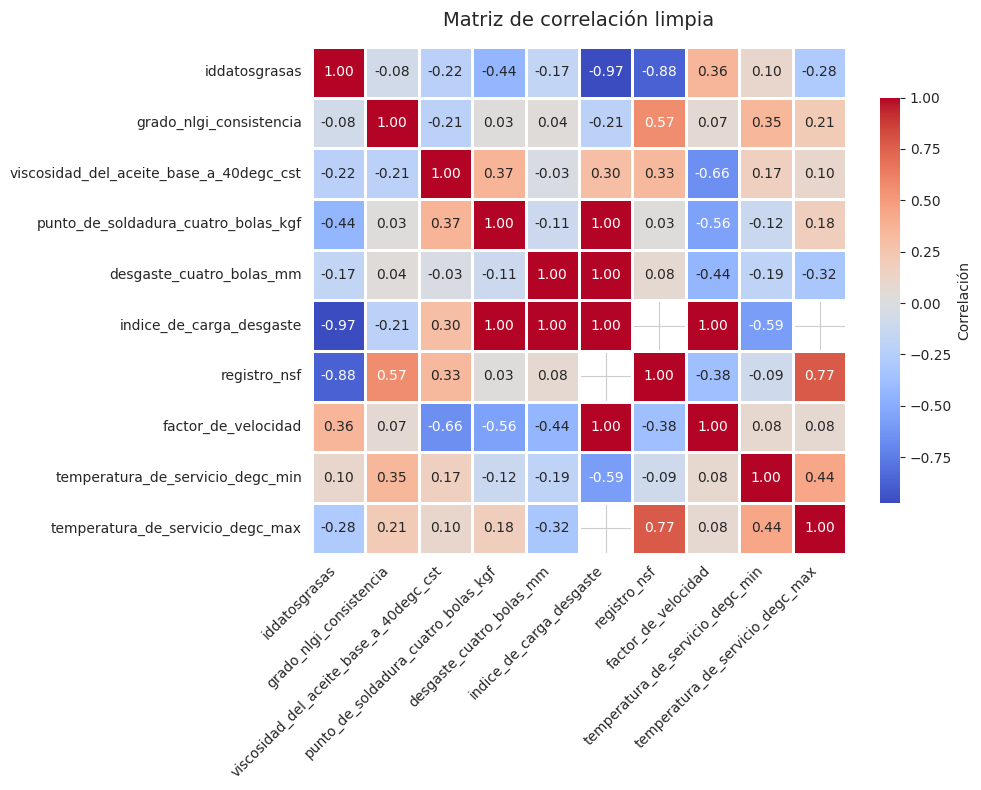

In [ ]:
corr_matrix = num_df.corr()

# Eliminar filas y columnas que sean completamente NaN
corr_matrix = corr_matrix.dropna(how="all", axis=0).dropna(how="all", axis=1)

# Visualización bonita
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

ax = sns.heatmap(
    corr_matrix,
    annot=True,          # mostrar valores
    fmt=".2f",           # 2 decimales
    cmap="coolwarm",     # escala de color
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Correlación"}
)

plt.title("Matriz de correlación limpia", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()